In [28]:
## Outlier Analysis on Shipping_Cost using IQR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Order_Delivery_Performance_Dataset (2).csv")



In [29]:
Q1 = df["Shipping_Cost"].quantile(0.25)
Q3 = df["Shipping_Cost"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

shipping_outliers = df[(df["Shipping_Cost"] < Lower) | (df["Shipping_Cost"] > Upper)]

print("Shipping Cost Outliers")
print(shipping_outliers)

print("Total Outliers:", len(shipping_outliers))

Shipping Cost Outliers
Empty DataFrame
Columns: [Order_ID, Customer_ID, Order_Date, Processing_Time_Hours, Shipping_Date, Expected_Delivery_Date, Actual_Delivery_Date, Delivery_Time_Days, Delivery_Status, Delay_Days, Cancellation, Cancellation_Reason, Courier, Warehouse, Region, Shipping_Cost, Order_Value, Customer_Rating, Payment_Method, Product_Category, Priority]
Index: []

[0 rows x 21 columns]
Total Outliers: 0


In [30]:
Q1 = df["Order_Value"].quantile(0.25)
Q3 = df["Order_Value"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

order_outliers = df[(df["Order_Value"] < Lower) | (df["Order_Value"] > Upper)]

print(order_outliers)

print("Total Outliers:", len(order_outliers))

Empty DataFrame
Columns: [Order_ID, Customer_ID, Order_Date, Processing_Time_Hours, Shipping_Date, Expected_Delivery_Date, Actual_Delivery_Date, Delivery_Time_Days, Delivery_Status, Delay_Days, Cancellation, Cancellation_Reason, Courier, Warehouse, Region, Shipping_Cost, Order_Value, Customer_Rating, Payment_Method, Product_Category, Priority]
Index: []

[0 rows x 21 columns]
Total Outliers: 0


In [31]:
df["Shipping_ZScore"] = (
    df["Shipping_Cost"] - df["Shipping_Cost"].mean()
) / df["Shipping_Cost"].std()

df["Order_ZScore"] = (
    df["Order_Value"] - df["Order_Value"].mean()
) / df["Order_Value"].std()

print("Shipping Cost Z-Score Outliers")

print(df[abs(df["Shipping_ZScore"]) > 3])

print()

print("Order Value Z-Score Outliers")

print(df[abs(df["Order_ZScore"]) > 3])

Shipping Cost Z-Score Outliers
Empty DataFrame
Columns: [Order_ID, Customer_ID, Order_Date, Processing_Time_Hours, Shipping_Date, Expected_Delivery_Date, Actual_Delivery_Date, Delivery_Time_Days, Delivery_Status, Delay_Days, Cancellation, Cancellation_Reason, Courier, Warehouse, Region, Shipping_Cost, Order_Value, Customer_Rating, Payment_Method, Product_Category, Priority, Shipping_ZScore, Order_ZScore]
Index: []

[0 rows x 23 columns]

Order Value Z-Score Outliers
Empty DataFrame
Columns: [Order_ID, Customer_ID, Order_Date, Processing_Time_Hours, Shipping_Date, Expected_Delivery_Date, Actual_Delivery_Date, Delivery_Time_Days, Delivery_Status, Delay_Days, Cancellation, Cancellation_Reason, Courier, Warehouse, Region, Shipping_Cost, Order_Value, Customer_Rating, Payment_Method, Product_Category, Priority, Shipping_ZScore, Order_ZScore]
Index: []

[0 rows x 23 columns]


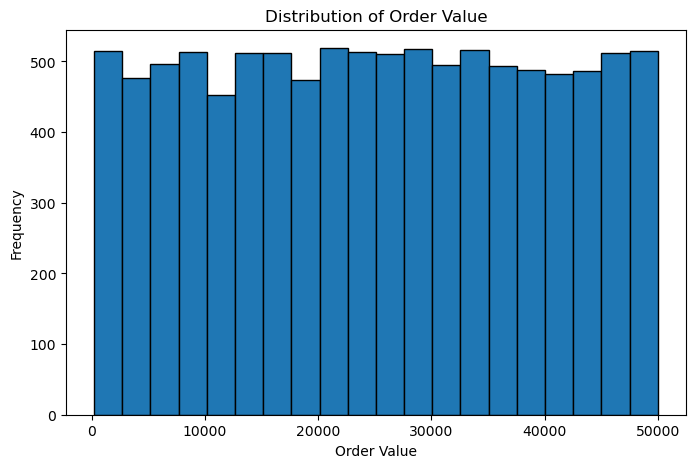

In [32]:


plt.figure(figsize=(8,5))

plt.hist(df["Order_Value"], bins=20, edgecolor="black")

plt.title("Distribution of Order Value")

plt.xlabel("Order Value")

plt.ylabel("Frequency")

plt.show()

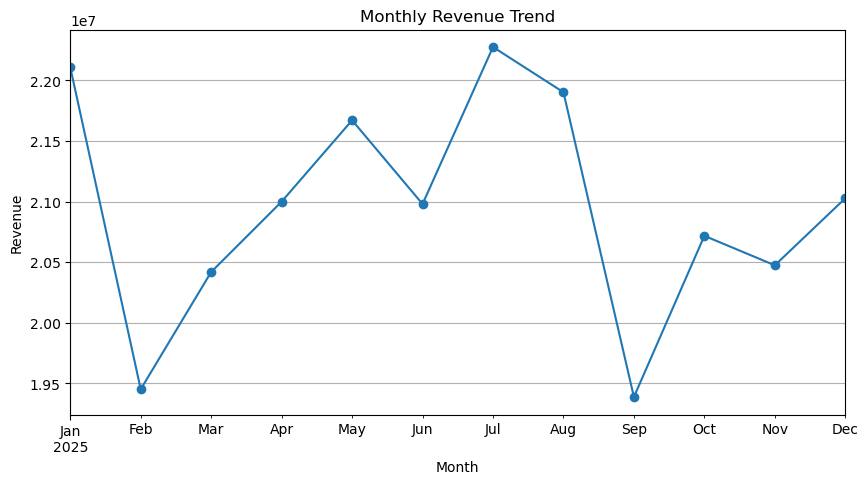

In [33]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Order_Value"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

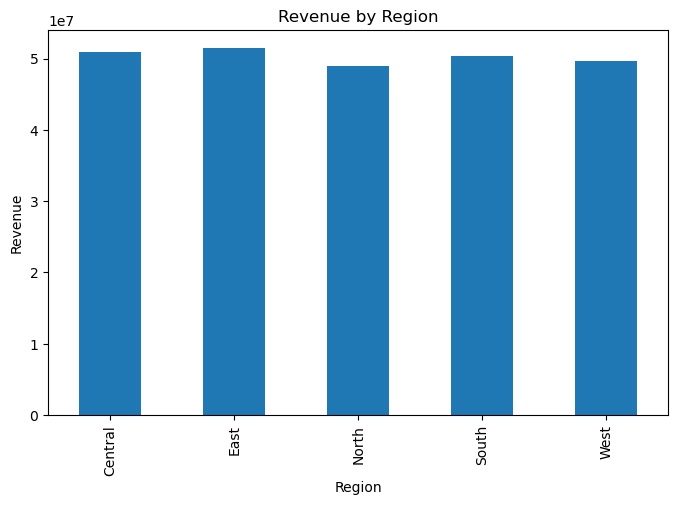

In [34]:
region_sales = df.groupby("Region")["Order_Value"].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

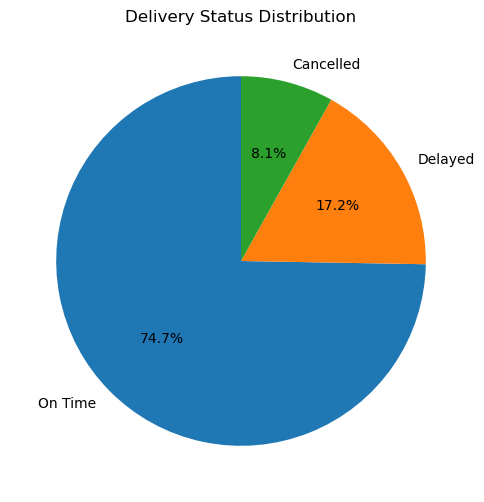

In [35]:
delivery = df["Delivery_Status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    delivery,
    labels=delivery.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Delivery Status Distribution")

plt.show()

In [36]:
print("Summary Statistics")
print(df[["Shipping_Cost","Order_Value"]].describe())

print("\nDelivery Status")
print(df["Delivery_Status"].value_counts())

print("\nRevenue by Region")
print(df.groupby("Region")["Order_Value"].sum())

print("\nRevenue by Product Category")
print(df.groupby("Product_Category")["Order_Value"].sum())

print("\nAverage Shipping Cost by Region")
print(df.groupby("Region")["Shipping_Cost"].mean())

Summary Statistics
       Shipping_Cost   Order_Value
count   10000.000000  10000.000000
mean      275.864800  25141.207900
std       130.602094  14363.168026
min        50.000000    203.000000
25%       162.000000  12876.500000
50%       277.000000  25185.500000
75%       390.000000  37423.000000
max       500.000000  49995.000000

Delivery Status
Delivery_Status
On Time      7472
Delayed      1716
Cancelled     812
Name: count, dtype: int64

Revenue by Region
Region
Central    50922941
East       51443037
North      49026875
South      50401160
West       49618066
Name: Order_Value, dtype: int64

Revenue by Product Category
Product_Category
Beauty         39886421
Electronics    42025440
Fashion        45007234
Grocery        41932007
Home           41232333
Sports         41328644
Name: Order_Value, dtype: int64

Average Shipping Cost by Region
Region
Central    276.510827
East       274.089706
North      274.854167
South      278.128127
West       275.796602
Name: Shipping_Cost, dt